In [1]:
#!pip install -q langchain langchain-openai langgraph python-dotenv flask

In [2]:
# !pip install openai python-dotenv pandas
import pandas as pd
import os, json, time
from dotenv import load_dotenv
from openai import OpenAI
import textwrap
import requests

import requests, json, textwrap

# Create a session that ignores proxy env vars (bypasses VPN for local Ollama)
SESSION = requests.Session()
SESSION.trust_env = False  # equivalent of ollama.Client(..., trust_env=False)



import truststore
truststore.inject_into_ssl()



def pretty_print(*args):
    text = " ".join(str(arg) for arg in args)
    try:
        print(textwrap.fill(text, width=80))
    except Exception as e:
        print(text)  # fallback to normal print if text is not a string

        

load_dotenv('/Users/shivam13juna/Documents/scaler/iitr_classes/llm_ref/openai_key.env')  # reads .env file in the current directory

api_key = os.getenv("OPENAI_API_KEY")

if not api_key:
    raise ValueError(
        "OPENAI_API_KEY not found! "
        "Make sure you have a .env file with: OPENAI_API_KEY=sk-..."
    )

pretty_print("API key loaded successfully.")

MODEL = 'gpt-5-nano'




client = OpenAI(api_key=api_key)
pretty_print("OpenAI client ready.")

print(f"Using model: {MODEL}")

API key loaded successfully.
OpenAI client ready.
Using model: gpt-5-nano


# Lang Chain

In [3]:
from langchain.chat_models import init_chat_model

# This uses the Responses API automatically!
llm = init_chat_model(f"openai:{MODEL}", api_key=api_key)

# Simple invocation
response = llm.invoke("Why is Donald Trump so bent on making my portfolio look so red?")
print(response.content)

Short answer: not exactly. One person isn’t able to “make” your portfolio red by themselves. Markets move on a lot of factors, and politics is just one of them. If you’re seeing red, it’s usually a mix of macro news, policy expectations, sector rotations, interest rates, and earnings, not a single person.

What Trump-style policy signals might influence markets (in general)
- Policy expectations: Tax plans, deregulation, or new tariffs can lift or sadden different sectors. If investors expect policies that hurt growth or disrupt supply chains, stocks can fall.
- Trade and geopolitics: Tariffs or trade tensions can create volatility and hurt globally diversified earnings.
- Regulation and energy policy: Deregulation can boost certain sectors (like financials or energy) while uncertainty can weigh on others.
- Communication and timing: Tweets and public statements can cause short-term swings as traders reassess likely policy moves.
- Elections and uncertainty: Campaigns and potential pol

In [4]:
from langchain_openai import ChatOpenAI

llm_explicit = ChatOpenAI(model=MODEL, api_key=api_key, temperature=0, use_responses_api=True)

response = llm_explicit.invoke("Why is Apple so red?")
print(response.content)

[{'id': 'rs_0aa978c4e020157f006a3168e702d0819d93b51e4650f8ed49', 'summary': [], 'type': 'reasoning', 'content': []}, {'type': 'text', 'text': 'Do you mean the fruit or the company Apple?\n\n- If you mean the fruit: Apples come in many colors, not just red. The red color comes from pigments called anthocyanins in the skin, which build up when the fruit is exposed to light and cooler temperatures. The amount and location of red blush depend on the apple variety (e.g., Red Delicious, Gala, Fuji), sun exposure, temperature during ripening, and how ripe the fruit is. Red helps attract animals to eat the fruit and disperse seeds.\n\n- If you mean Apple the company: Apple isn’t always red. Their logo and branding are often white or black, but they sometimes use red in product colors, most notably the (PRODUCT)RED line where some devices are sold in red to support a charity partner. Red is used for visibility and marketing, and to raise funds for HIV/AIDS relief.\n\nIf you tell me which one yo

In [5]:
from langchain.messages import HumanMessage, SystemMessage, AIMessage

messages = [
    SystemMessage(content="You are a friendly NovaMart customer support agent. Keep answers brief."),
    HumanMessage(content="What's your return policy?")
]

response = llm.invoke(messages)
print(response.content)

NovaMart return policy (summary):

- 30-day return window from delivery for most items.
- Items must be unused and in original packaging, with proof of purchase.
- Refunds go to the original payment method after the return is received/inspected.
- Return shipping is customer’s responsibility unless the item is defective or incorrect.
- Some items may be non-returnable per the product page.

To start a return, go to your NovaMart account > Orders > Return, or share your order number and I’ll help.


In [6]:
messages = [
    SystemMessage(content="You are a friendly NovaMart customer support agent. Keep answers brief."),
    HumanMessage(content="What's your return policy?"),
    AIMessage(content="You can return most items within 30 days with the receipt."),
    HumanMessage(content="What if I opened the package?")
]

response = llm.invoke(messages)
print(response.content)

Opening isn’t a problem. Our 30-day return window applies, as long as the item is in its original condition with all packaging and accessories. Some items have exceptions (electronics, opened personal care, etc.). Share your order number and the item name and we’ll confirm eligibility and next steps.


# Tools in LangChain

In [ ]:
#In Openai Responses API
#1. create tool-schema
#2. create tool
#3. Provide tool to the api.

In [7]:
from langchain.tools import tool

NOVAMART_FAQ = {
    "return policy": "NovaMart offers a 30-day no-questions-asked return policy for all items in original packaging.",
    "shipping time": "Standard shipping takes 3-5 business days. Express shipping takes 1-2 business days.",
    "payment methods": "We accept Visa, Mastercard, PayPal, and NovaPay wallet.",
    "warranty": "All electronics come with a 1-year manufacturer warranty. Extended warranty available for $29/year.",
    "contact": "Email: help@novamart.com | Phone: 1-800-NOVA | Live chat available 24/7.",
}

# ----- NovaMart Order Database -----
NOVAMART_ORDERS = {
    "NM-90210": {"status": "shipped", "eta": "March 15", "item": "Wireless Headphones", "carrier": "FedEx"},
    "NM-10042": {"status": "processing", "eta": "March 18", "item": "Smart Watch Pro", "carrier": "TBD"},
    "NM-55331": {"status": "delivered", "eta": "March 10", "item": "USB-C Hub", "carrier": "UPS"},
}

@tool
def faq_lookup(topic: str) -> str:
    """Look up NovaMart FAQ by topic. Available topics: return policy, shipping time, payment methods, warranty, contact."""
    result = NOVAMART_FAQ.get(topic.lower(), None)
    if result:
        return result
    return f"No FAQ entry found for '{topic}'. Available topics: {', '.join(NOVAMART_FAQ.keys())}"



@tool
def order_tracker(order_id: str) -> str:
    """Track a NovaMart order by its ID (e.g., NM-90210)."""
    order = NOVAMART_ORDERS.get(order_id.upper(), None)
    if order:
        return f"Order {order_id}: {order['item']} — Status: {order['status']}, ETA: {order['eta']}, Carrier: {order['carrier']}"
    return f"Order {order_id} not found. Please double-check the order ID."



In [8]:

GEOCODE_URL = "https://geocoding-api.open-meteo.com/v1/search"
FORECAST_URL = "https://api.open-meteo.com/v1/forecast"

WEATHER_CODE_MAP = {
    0: "Clear sky",
    1: "Mainly clear",
    2: "Partly cloudy",
    3: "Overcast",
    45: "Fog",
    48: "Depositing rime fog",
    51: "Light drizzle",
    53: "Moderate drizzle",
    55: "Dense drizzle",
    56: "Light freezing drizzle",
    57: "Dense freezing drizzle",
    61: "Slight rain",
    63: "Moderate rain",
    65: "Heavy rain",
    66: "Light freezing rain",
    67: "Heavy freezing rain",
    71: "Slight snow fall",
    73: "Moderate snow fall",
    75: "Heavy snow fall",
    77: "Snow grains",
    80: "Slight rain showers",
    81: "Moderate rain showers",
    82: "Violent rain showers",
    85: "Slight snow showers",
    86: "Heavy snow showers",
    95: "Thunderstorm",
    96: "Thunderstorm with slight hail",
    99: "Thunderstorm with heavy hail",
}


@tool
def get_weather(location: str) -> str:
    """Get the current weather for a city using Open-Meteo."""
    try:
        # 1) Geocode the location name -> lat/lon
        geo_resp = SESSION.get(
            GEOCODE_URL,
            params={"name": location, "count": 1, "language": "en", "format": "json"},
            timeout=15,
        )
        geo_resp.raise_for_status()
        geo_data = geo_resp.json()

        results = geo_data.get("results")
        if not results:
            return f"Could not find location '{location}'."

        place = results[0]
        name = place.get("name", location)
        country = place.get("country", "")
        admin1 = place.get("admin1", "")
        latitude = place["latitude"]
        longitude = place["longitude"]

        # 2) Fetch current weather
        forecast_resp = SESSION.get(
            FORECAST_URL,
            params={
                "latitude": latitude,
                "longitude": longitude,
                "current": ",".join([
                    "temperature_2m",
                    "relative_humidity_2m",
                    "apparent_temperature",
                    "is_day",
                    "precipitation",
                    "weather_code",
                    "wind_speed_10m",
                    "wind_direction_10m",
                ]),
                "timezone": "auto",
            },
            timeout=15,
        )
        forecast_resp.raise_for_status()
        forecast_data = forecast_resp.json()

        current = forecast_data.get("current")
        if not current:
            return f"Weather data was unavailable for '{location}'."

        weather_code = current.get("weather_code")
        weather_desc = WEATHER_CODE_MAP.get(weather_code, f"Unknown ({weather_code})")

        place_bits = [name]
        if admin1:
            place_bits.append(admin1)
        if country:
            place_bits.append(country)
        place_str = ", ".join(place_bits)

        return (
            f"Current weather for {place_str}:\n"
            f"- Condition: {weather_desc}\n"
            f"- Temperature: {current.get('temperature_2m')}°C\n"
            f"- Feels like: {current.get('apparent_temperature')}°C\n"
            f"- Humidity: {current.get('relative_humidity_2m')}%\n"
            f"- Wind: {current.get('wind_speed_10m')} km/h "
            f"at {current.get('wind_direction_10m')}°\n"
            f"- Precipitation: {current.get('precipitation')} mm\n"
            f"- Daytime: {'Yes' if current.get('is_day') == 1 else 'No'}\n"
            f"- Time: {current.get('time')}"
        )

    except requests.RequestException as e:
        return f"Network/API error while fetching weather for '{location}': {e}"
    except Exception as e:
        return f"Unexpected error while fetching weather for '{location}': {e}"
    

print(get_weather.invoke({"location": "Delhi"}))
print()
print(get_weather.invoke({"location": "Rehovot"}))

# Quick test — calling tools directly
print(faq_lookup.invoke({"topic": "return policy"}))
print()
print(order_tracker.invoke({"order_id": "NM-90210"}))

Current weather for Delhi, National Capital Territory of Delhi, India:
- Condition: Clear sky
- Temperature: 28.8°C
- Feels like: 32.6°C
- Humidity: 62%
- Wind: 3.4 km/h at 148°
- Precipitation: 0.0 mm
- Daytime: No
- Time: 2026-06-16T20:45

Current weather for Rehovot, Central District, Israel:
- Condition: Mainly clear
- Temperature: 26.4°C
- Feels like: 28.0°C
- Humidity: 67%
- Wind: 14.3 km/h at 342°
- Precipitation: 0.0 mm
- Daytime: Yes
- Time: 2026-06-16T18:15
NovaMart offers a 30-day no-questions-asked return policy for all items in original packaging.

Order NM-90210: Wireless Headphones — Status: shipped, ETA: March 15, Carrier: FedEx


In [9]:
# Bind tools to the LLM
llm_with_tools = llm.bind_tools([faq_lookup, order_tracker, get_weather])

In [10]:
response = llm_with_tools.invoke("Where is my order NM-90210?")

In [11]:
print("Content:", response.content)
print()
print("Tool calls:", response.tool_calls)

Content: 

Tool calls: [{'name': 'order_tracker', 'args': {'order_id': 'NM-90210'}, 'id': 'call_bLKwGtLkHbgdanIaN7ZyjjIW', 'type': 'tool_call'}]


## LangChain Agent

In [12]:
from langchain.agents import create_agent

support_agent = create_agent(
    model=f"openai:{MODEL}",
    tools=[faq_lookup, order_tracker, get_weather],
    system_prompt="You are NovaMart's friendly customer support agent. Use your tools to answer customer questions accurately. Be concise and helpful."
)

print("✅ Agent created! Type:", type(support_agent).__name__)

✅ Agent created! Type: CompiledStateGraph


In [16]:
#result = support_agent.invoke(
#    {"messages": [{"role": "user", "content": "Hi! Can you check where my order NM-90210 is?"}]}
#)

result = support_agent.invoke(
    {"messages": [HumanMessage(content="Hi! Can you check where my order NM-90210 is?")]}
)

for msg in result["messages"]:
    role = msg.__class__.__name__
    content = str(msg.content)[:200] if msg.content else "(tool call)"
    print(f"[{role}] {content}")
    print()

[HumanMessage] Hi! Can you check where my order NM-90210 is?

[AIMessage] (tool call)

[ToolMessage] Order NM-90210: Wireless Headphones — Status: shipped, ETA: March 15, Carrier: FedEx

[AIMessage] Here’s the latest on NM-90210:
- Status: Shipped
- Carrier: FedEx
- Estimated delivery: March 15

Would you like me to pull the tracking number and a live tracking link, or set up delivery alerts for 



In [ ]:
 # ( 3 + 4) * (8 + 5)

# function for sending message to someone

In [17]:
for event in support_agent.stream(
    {"messages": [{"role": "user", "content": "Tell me status of order NM-55331. I need to return order NM-55331. What's the return policy? And I also want to know the temperature and weather of Tehran?"}]},
    stream_mode="updates"
):
    for node_name, node_output in event.items():
        print(f"--- {node_name} ---")
        if "messages" in node_output:
            for msg in node_output["messages"]:
                role = msg.__class__.__name__
                content = str(msg.content) if msg.content else "(tool call request)"
                # If this is an AI message and it requested tool calls
                if hasattr(msg, "tool_calls") and msg.tool_calls:
                    print("    Tool calls:")
                    for tc in msg.tool_calls:
                        print(f"      - tool name: {tc.get('name')}")
                        print(f"        args: {tc.get('args')}")
                        print(f"        id: {tc.get('id')}")
                print(f"  [{role}] {content}")
        print()

--- model ---
    Tool calls:
      - tool name: order_tracker
        args: {'order_id': 'NM-55331'}
        id: call_O9oys8QUCQOZat7ePmDuziH2
      - tool name: faq_lookup
        args: {'topic': 'return policy'}
        id: call_VHycg19griZNp8lFgR2UX82i
      - tool name: get_weather
        args: {'location': 'Tehran'}
        id: call_sYpoZBTpSTbDUuoRlgVvMRdH
  [AIMessage] (tool call request)

--- tools ---
  [ToolMessage] Order NM-55331: USB-C Hub — Status: delivered, ETA: March 10, Carrier: UPS

--- tools ---
  [ToolMessage] NovaMart offers a 30-day no-questions-asked return policy for all items in original packaging.

--- tools ---
  [ToolMessage] Current weather for Tehran, Tehran, Iran:
- Condition: Clear sky
- Temperature: 30.7°C
- Feels like: 27.9°C
- Humidity: 17%
- Wind: 7.6 km/h at 239°
- Precipitation: 0.0 mm
- Daytime: Yes
- Time: 2026-06-16T19:00

--- model ---
  [AIMessage] Here’s what I found:

- Order NM-55331 status
  - Item: USB-C Hub
  - Status: Delivered
  - Ca

## Adding memory to the agent (LangChain Memory)

In [18]:
from langgraph.checkpoint.memory import InMemorySaver

# Create agent WITH memory
memory = InMemorySaver()

support_agent_with_memory = create_agent(
    model=f"openai:{MODEL}",
    tools=[faq_lookup, order_tracker, get_weather],
    system_prompt="You are NovaMart's friendly customer support agent. Use your tools to answer customer questions accurately. Be concise and helpful.",
    checkpointer=memory
)

# Thread config — think of this as a "conversation ID"
config = {"configurable": {"thread_id": "customer-session-001"}}

# First message
result = support_agent_with_memory.invoke(
    {"messages": [{"role": "user", "content": "Hi! I'm Alice. Can you check order NM-10042?"}]},
    config=config
)
print("🤖 Agent:", result["messages"][-1].text)


🤖 Agent: Hi Alice! Here’s the latest on NM-10042:

- Item: Smart Watch Pro
- Status: Processing
- ETA: March 18
- Carrier: To Be Determined

Would you like me to set up notifications (email or SMS) for when it ships, or re-check the status closer to the ETA? I can also help confirm or update your shipping address if needed.


In [19]:
result = support_agent_with_memory.invoke(
    {"messages": [{"role": "user", "content": "What about NM-90210? and what's my name?"}]},
    config=config
)
print("🤖 Agent:", result["messages"][-1].text)

🤖 Agent: NM-90210 is shipped.

- Item: Wireless Headphones
- Status: Shipped
- ETA: March 15
- Carrier: FedEx

And your name is Alice.

Would you like me to pull the tracking number or set up delivery notifications (email or SMS) for NM-90210? I can also re-check status closer to the ETA.


In [20]:
result = support_agent_with_memory.invoke(
    {"messages": [{"role": "user", "content": "What have we talked about so far?"}]},
    config=config
)
print("🤖 Agent:", result["messages"][-1].text)

🤖 Agent: Here’s a quick recap of our chat:

- NM-10042 (Smart Watch Pro): Status – processing; ETA – March 18; Carrier – To Be Determined. I offered to set up notifications or update your shipping address if needed.
- NM-90210 (Wireless Headphones): Status – shipped; ETA – March 15; Carrier – FedEx. I offered to pull the tracking number or set up delivery notifications, and to re-check status closer to the ETA.
- Your name: Alice. 

Would you like me to set up notifications for either order, pull tracking numbers, or update any details?


# LangGraph

In [24]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END


In [25]:
class SimpleState(TypedDict):
    message: str
    steps: list



def greet(state: SimpleState):
    return {
        "message": "Hello from NovaMart!",
        "steps": state.get("steps", []) + ["greet"]
    }


def classify(state: SimpleState):
    return {
        "message": state["message"] + " How can we help you today?",
        "steps": state["steps"] + ["classify"]
    }



builder = StateGraph(SimpleState) # create a blank graph with the state type defined above, like an empty canvas. 
builder.add_node("greet", greet)
builder.add_node("classify", classify)

builder.add_edge(START, "greet")
builder.add_edge("greet", "classify")
builder.add_edge("classify", END)


simple_graph = builder.compile()

In [27]:
simple_graph.invoke({"message": "", "steps": []})

{'message': 'Hello from NovaMart! How can we help you today?',
 'steps': ['greet', 'classify']}

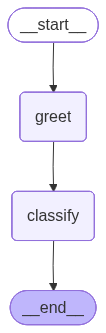

In [26]:
from IPython.display import Image, display

try:
    display(Image(simple_graph.get_graph().draw_mermaid_png()))
except Exception as e:
    # Fallback: print Mermaid text
    print(simple_graph.get_graph().draw_mermaid())

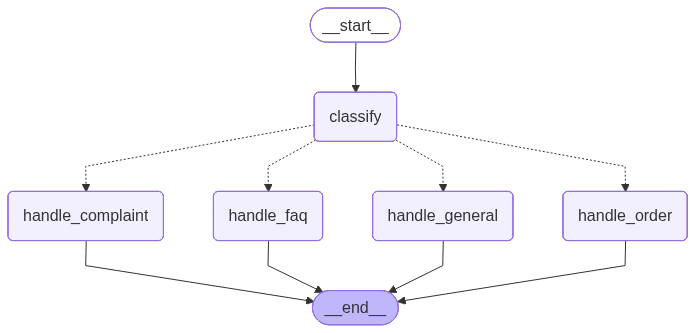

In [29]:
def show_graph(graph, title=None):
    """Draw any LangGraph graph inline.

    `graph` may be a builder (StateGraph, e.g. `g`) OR an already-compiled
    graph (e.g. `flow`) — both work. Renders a PNG; if there's no network,
    falls back to Mermaid text so it never hard-fails.
    """
    # Compiled graphs expose .get_graph(); a builder must be compiled first.
    drawable = (graph if hasattr(graph, "get_graph") else graph.compile()).get_graph()
    if title:
        print(title)
    try:
        display(Image(drawable.draw_mermaid_png()))      # pretty PNG (needs internet)
    except Exception as e:
        print(f"(PNG unavailable: {e}) — showing Mermaid text instead:\n")
        print(drawable.draw_mermaid())

print("✅ show_graph() ready — call show_graph(g) or show_graph(flow) on any graph.")

✅ show_graph() ready — call show_graph(g) or show_graph(flow) on any graph.


In [39]:
from typing import Literal, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain.messages import HumanMessage, AIMessage, SystemMessage
from langchain_openai import ChatOpenAI

In [35]:
class TrailState(TypedDict):
    steps: list         

def stage_one(state):   return {"steps": ["stage_one"]}
def stage_two(state):   return {"steps": ["stage_two"]}
def stage_three(state): return {"steps": ["stage_three"]}

g = StateGraph(TrailState)
g.add_node("stage_one", stage_one)
g.add_node("stage_two", stage_two)
g.add_node("stage_three", stage_three)


g.add_edge(START, "stage_one")
g.add_edge("stage_one", "stage_two")
g.add_edge("stage_two", "stage_three")
g.add_edge("stage_three", END)
trail = g.compile()

result = trail.invoke({"steps": []})
print("steps =", result["steps"])
print("\n😱 We ran THREE stages but only the LAST one survived.")
print("   Each return OVERWROTE 'steps' instead of adding to it.")

# [['stage_one'], ['stage_two'], ['stage_three']]

steps = ['stage_three']

😱 We ran THREE stages but only the LAST one survived.
   Each return OVERWROTE 'steps' instead of adding to it.


This graph has a reducer problem. The state doesn't accumulate as it should.


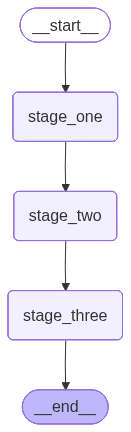

In [32]:
show_graph(g, title="This graph has a reducer problem. The state doesn't accumulate as it should.")

In [36]:
import operator

operator.add(2, 3)

5

In [37]:
operator.add('a', 'b')

'ab'

In [38]:
operator.add([1], [2])

[1, 2]

In [40]:
class TrailState(TypedDict):
    steps: Annotated[list, operator.add]       

def stage_one(state):   return {"steps": ["stage_one"]}
def stage_two(state):   return {"steps": ["stage_two"]}
def stage_three(state): return {"steps": ["stage_three"]}

g = StateGraph(TrailState)
g.add_node("stage_one", stage_one)
g.add_node("stage_two", stage_two)
g.add_node("stage_three", stage_three)


g.add_edge(START, "stage_one")
g.add_edge("stage_one", "stage_two")
g.add_edge("stage_two", "stage_three")
g.add_edge("stage_three", END)
trail = g.compile()

result = trail.invoke({"steps": []})
print("steps =", result["steps"])
print("\n😱 We ran THREE stages but only the LAST one survived.")
print("   Each return OVERWROTE 'steps' instead of adding to it.")

# [['stage_one'], ['stage_two'], ['stage_three']]

steps = ['stage_one', 'stage_two', 'stage_three']

😱 We ran THREE stages but only the LAST one survived.
   Each return OVERWROTE 'steps' instead of adding to it.


In [42]:
llm = ChatOpenAI(model=MODEL, temperature=0, use_responses_api=True, api_key=api_key)



class SupportState(TypedDict):
    messages: Annotated[list, add_messages]
    intent: str


def classify_intent(state: SupportState):
    last_msg = state["messages"][-1].content if state["messages"] else ""

    classification_prompt = [
        SystemMessage(content="""Classify the customer message into exactly one category.
Reply with ONLY the category name, nothing else.
Categories: faq, order_tracking, complaint, general"""),
        HumanMessage(content=last_msg)
    ]

    result = llm.invoke(classification_prompt)
    intent = result.text.strip().lower()

    # Normalize
    if "faq" in intent:
        intent = "faq"
    elif "order" in intent or "track" in intent:
        intent = "order_tracking"
    elif "complaint" in intent:
        intent = "complaint"
    else:
        intent = "general"

    return {"intent": intent}


def handle_faq(state: SupportState):
    last_msg = state["messages"][-1].content
    llm_with_faq = llm.bind_tools([faq_lookup]) # we attach the tool to the LLM so it can call it when needed
    response = llm_with_faq.invoke([
        SystemMessage(content="Answer the customer's FAQ question using the faq_lookup tool. Be helpful and concise."),
        HumanMessage(content=last_msg)
    ]) # output of function-call, i.e. the LLM's response to the above prompt, which may include tool calls in response.tool_calls with arguments. 

    if response.tool_calls:
        tool_result = faq_lookup.invoke(response.tool_calls[0]["args"])
        final = llm.invoke([
            SystemMessage(content="Rewrite this FAQ answer in a friendly customer-support tone:"),
            HumanMessage(content=tool_result)
        ])
        return {"messages": [AIMessage(content=final.content)]}

    return {"messages": [response]}


# Hey man!! I'm really mad today, my order NM-55331 hasn't arrived at all!!! it was supposed to be here 5 days ago. Can you check where it is? 


# ----- Node: Handle Order Tracking -----
def handle_order(state: SupportState):
    last_msg = state["messages"][-1].content
    llm_with_tracker = llm.bind_tools([order_tracker])
    response = llm_with_tracker.invoke([
        SystemMessage(content="Track the customer's order using the order_tracker tool. Extract the order ID from their message."),
        HumanMessage(content=last_msg)
    ])

    if response.tool_calls:
        tool_result = order_tracker.invoke(response.tool_calls[0]["args"])
        final = llm.invoke([
            SystemMessage(content="Present this order tracking info in a friendly way:"),
            HumanMessage(content=tool_result)
        ])
        return {"messages": [AIMessage(content=final.content)]}

    return {"messages": [response]}

# ----- Node: Handle Complaint -----
def handle_complaint(state: SupportState):
    last_msg = state["messages"][-1].content
    response = llm.invoke([
        SystemMessage(content="You are NovaMart support. The customer has a complaint. Acknowledge their frustration, apologize sincerely, and offer to escalate. Be empathetic."),
        HumanMessage(content=last_msg)
    ])
    return {"messages": [response]}

# ----- Node: Handle General -----
def handle_general(state: SupportState):
    last_msg = state["messages"][-1].content
    response = llm.invoke([
        SystemMessage(content="You are NovaMart's friendly support agent. Answer the customer's general question helpfully."),
        HumanMessage(content=last_msg)
    ])
    return {"messages": [response]}

# ----- Router function -----
def route_by_intent(state: SupportState) -> Literal["handle_faq", "handle_order", "handle_complaint", "handle_general"]:
    intent = state.get("intent", "general")
    mapping = {
        "faq": "handle_faq",
        "order_tracking": "handle_order",
        "complaint": "handle_complaint",
        "general": "handle_general"
    } # mapping of intent to node-name
    return mapping.get(intent, "handle_general")


In [43]:

builder = StateGraph(SupportState)

builder.add_node("classify", classify_intent)
builder.add_node("handle_faq", handle_faq)
builder.add_node("handle_order", handle_order)
builder.add_node("handle_complaint", handle_complaint)
builder.add_node("handle_general", handle_general)

builder.add_edge(START, "classify") # output of a normal node is an update to stategraph, output of a conditional edge is a routing decision based on the state.
builder.add_conditional_edges("classify", route_by_intent)
builder.add_edge("handle_faq", END)
builder.add_edge("handle_order", END)
builder.add_edge("handle_complaint", END)
builder.add_edge("handle_general", END)

custom_agent = builder.compile()

print("✅ Custom NovaMart support graph built!")

✅ Custom NovaMart support graph built!


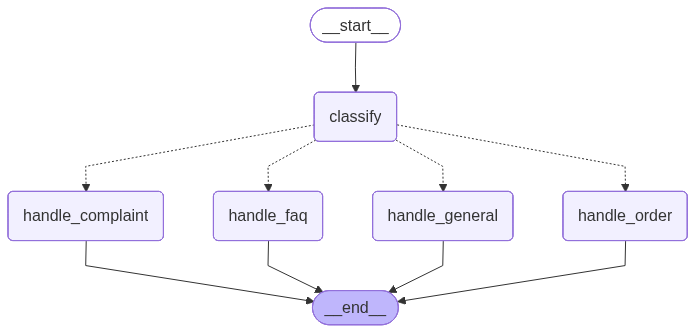

In [44]:
# Visualize our custom graph
try:
    display(Image(custom_agent.get_graph().draw_mermaid_png()))
except Exception:
    print(custom_agent.get_graph().draw_mermaid())

In [45]:
# Test FAQ path
result = custom_agent.invoke({
    "messages": [HumanMessage(content="What's your return policy?")],
    "intent": ""
})
print("📋 FAQ Test")
print("Intent:", result["intent"])
print("🤖 Agent:", result["messages"][-1].text)
print()

📋 FAQ Test
Intent: faq
🤖 Agent: Here at NovaMart, we want you to shop with confidence. If you’re not completely satisfied, you can return any item within 30 days—no questions asked—as long as it’s in its original packaging.



In [46]:
# Test Order Tracking path
result = custom_agent.invoke({
    "messages": [HumanMessage(content="Where is my order NM-90210?")],
    "intent": ""
})
print("📦 Order Tracking Test")
print("Intent:", result["intent"])
print("🤖 Agent:", result["messages"][-1].text)
print()

📦 Order Tracking Test
Intent: order_tracking
🤖 Agent: Here’s your order update:

- Order: NM-90210
- Item: Wireless Headphones
- Status: Shipped
- Carrier: FedEx
- Estimated delivery: March 15

If you have the tracking number, I can pull up the live tracking for you or set a delivery reminder. Want me to do either?



In [47]:
# Test Order Tracking path
result = custom_agent.invoke({
    "messages": [HumanMessage(content="I need to talk to your manager!!!")],
    "intent": ""
})
print("📦 Order Tracking Test")
print("Intent:", result["intent"])
print("🤖 Agent:", result["messages"][-1].text)
print()

📦 Order Tracking Test
Intent: complaint
🤖 Agent: I’m really sorry you’re dealing with this, and I understand you want to talk to a manager. I can escalate this right away and have a supervisor review your case.

To get you to the right person quickly, could you share:
- Your order number or account email
- A brief description of the issue and what happened
- Any relevant dates or reference numbers
- Your preferred contact method (phone or email) and the best time to reach you

If you’d like, I can create a formal escalation ticket now and give you a case number. Once I have the details, I’ll escalate immediately and a supervisor will follow up as soon as possible. Would you like me to proceed?



In [48]:
result

{'messages': [HumanMessage(content='I need to talk to your manager!!!', additional_kwargs={}, response_metadata={}, id='c569d2be-76bc-4125-a1f6-52be91f43272'),
  AIMessage(content=[{'id': 'rs_0457c626e726685f006a317ba41450819f8ccadcced0e9fbca', 'summary': [], 'type': 'reasoning', 'content': []}, {'type': 'text', 'text': 'I’m really sorry you’re dealing with this, and I understand you want to talk to a manager. I can escalate this right away and have a supervisor review your case.\n\nTo get you to the right person quickly, could you share:\n- Your order number or account email\n- A brief description of the issue and what happened\n- Any relevant dates or reference numbers\n- Your preferred contact method (phone or email) and the best time to reach you\n\nIf you’d like, I can create a formal escalation ticket now and give you a case number. Once I have the details, I’ll escalate immediately and a supervisor will follow up as soon as possible. Would you like me to proceed?', 'annotations'

In [49]:
#Ask a question, and get an answer. 

In [ ]:

#RAG + LLM

#Chroma

